<a href="https://colab.research.google.com/github/cysorianoc/Hugging_Face/blob/main/Notebook_7_object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 8: Object Detection

We will apply here computer vision concepts.

- In the classroom, the libraries are already installed for you.
- If you would like to run this code on your own machine, you can install the following:

```
    !pip install transformers
    !pip install gradio
    !pip install timm
    !pip install inflect
    !pip install phonemizer
```

**Note:**  `py-espeak-ng` is only available Linux operating systems.

To run locally in a Linux machine, follow these commands:
```
    sudo apt-get update
    sudo apt-get install espeak-ng
    pip install py-espeak-ng
```

### Build the `object-detection` pipeline using 🤗 Transformers Library

- This model was release with the paper [End-to-End Object Detection with Transformers](https://arxiv.org/abs/2005.12872) from Carion et al. (2020)

In [ ]:
# We need some helper functions: just run to write helper.py file
%%writefile helper.py

import io
import matplotlib.pyplot as plt
import requests
import inflect
from PIL import Image

def load_image_from_url(url):
    return Image.open(requests.get(url, stream=True).raw)

def render_results_in_image(in_pil_img, in_results):
    plt.figure(figsize=(16, 10))
    plt.imshow(in_pil_img)

    ax = plt.gca()

    for prediction in in_results:

        x, y = prediction['box']['xmin'], prediction['box']['ymin']
        w = prediction['box']['xmax'] - prediction['box']['xmin']
        h = prediction['box']['ymax'] - prediction['box']['ymin']

        ax.add_patch(plt.Rectangle((x, y),
                                   w,
                                   h,
                                   fill=False,
                                   color="green",
                                   linewidth=2))
        ax.text(
           x,
           y,
           f"{prediction['label']}: {round(prediction['score']*100, 1)}%",
           color='red'
        )

    plt.axis("off")

    # Save the modified image to a BytesIO object
    img_buf = io.BytesIO()
    plt.savefig(img_buf, format='png',
                bbox_inches='tight',
                pad_inches=0)
    img_buf.seek(0)
    modified_image = Image.open(img_buf)

    # Close the plot to prevent it from being displayed
    plt.close()

    return modified_image

def summarize_predictions_natural_language(predictions):
    summary = {}
    p = inflect.engine()

    for prediction in predictions:
        label = prediction['label']
        if label in summary:
            summary[label] += 1
        else:
            summary[label] = 1

    result_string = "In this image, there are "
    for i, (label, count) in enumerate(summary.items()):
        count_string = p.number_to_words(count)
        result_string += f"{count_string} {label}"
        if count > 1:
          result_string += "s"

        result_string += " "

        if i == len(summary) - 2:
          result_string += "and "

    # Remove the trailing comma and space
    result_string = result_string.rstrip(', ') + "."

    return result_string


##### To ignore warnings #####
import warnings
import logging
from transformers import logging as hf_logging

def ignore_warnings():
    # Ignore specific Python warnings
    warnings.filterwarnings("ignore", message="Some weights of the model checkpoint")
    warnings.filterwarnings("ignore", message="Could not find image processor class")
    warnings.filterwarnings("ignore", message="The `max_size` parameter is deprecated")

    # Adjust logging for libraries using the logging module
    logging.basicConfig(level=logging.ERROR)
    hf_logging.set_verbosity_error()

########

Writing helper.py


In [ ]:
# We import the utility methods for this notebook
import sys
if 'helper' in sys.modules:
    del sys.modules['helper']
from helper import load_image_from_url, render_results_in_image

In [ ]:
# We now import the pipeline
from transformers import pipeline

- Here is some code that suppresses warning messages.

In [ ]:
from transformers.utils import logging
logging.set_verbosity_error()

from helper import ignore_warnings
ignore_warnings()

In [ ]:
# WE now load the object detection pipeline
od_pipe = pipeline("object-detection", "facebook/detr-resnet-50")

config.json:   0%|          | 0.00/4.59k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  167MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

# What is object detection ?

The goal is to detect all the objects of interest in an specific image

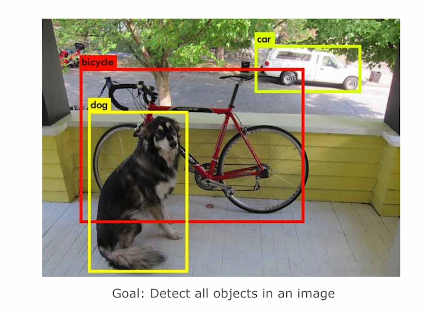




Object detection combines two subtasks: classification and location

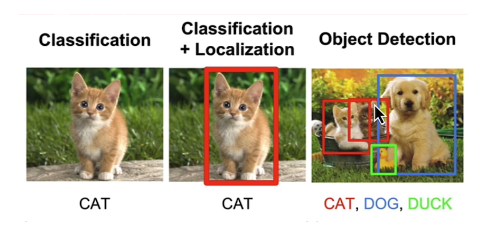

We can filter among all available models on Hugging Face and choose those for object detection. WE can select it by te number of parameters, the most liked, the most downloaded and so on.


Info about [facebook/detr-resnet-50](https://huggingface.co/facebook/detr-resnet-50)

Explore more of the [Hugging Face Hub for more object detection models](https://huggingface.co/models?pipeline_tag=object-detection&sort=trending)

### Use the Pipeline

In [ ]:
# Let's import PIL library to manipulate images
from PIL import Image
from io import BytesIO
import requests

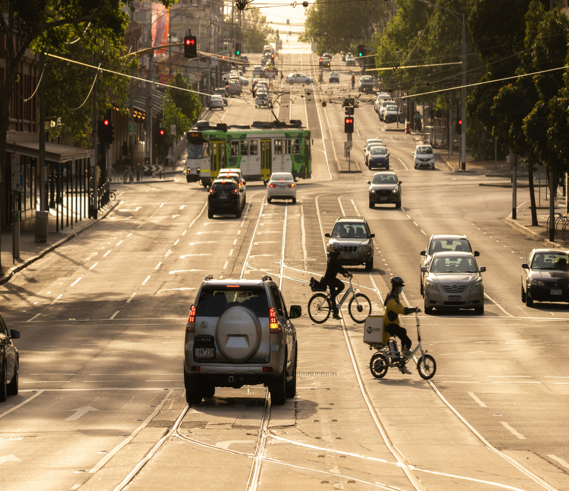

In [ ]:
# Let's load an image from an URL
url="https://raw.githubusercontent.com/cysorianoc/Hugging_Face/main/sample_image.jpg"
response=requests.get(url)
raw_image=Image.open(BytesIO(response.content))
raw_image.resize((569, 491))

In [ ]:
#Now lets pass the image into the pipeline
pipeline_output = od_pipe(raw_image)

- Return the results from the pipeline using the helper function `render_results_in_image`.

In [ ]:
processed_image = render_results_in_image(
    raw_image,
    pipeline_output)

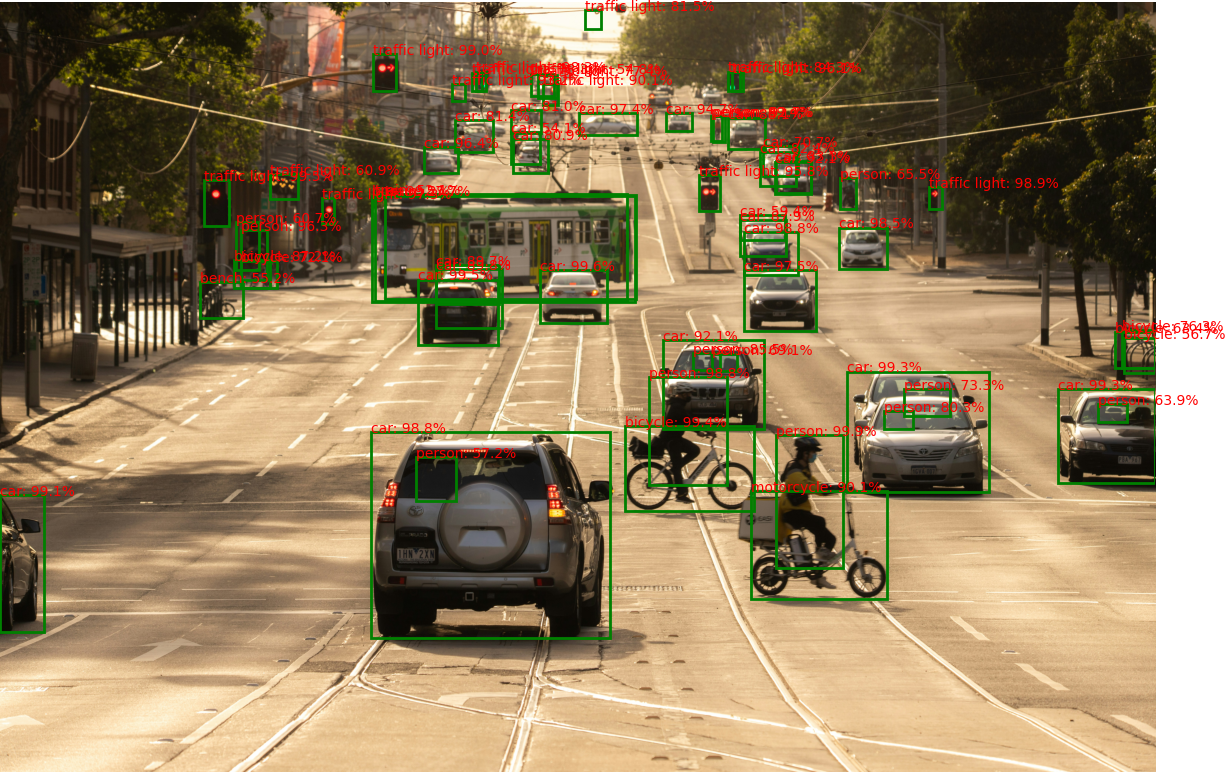

In [ ]:
processed_image

### Using `Gradio` as a Simple Interface

- Use [Gradio](https://www.gradio.app) to create a demo for the object detection app.
- The demo makes it look friendly and easy to use.
- You can share the demo with your friends and colleagues as well.

In [ ]:
import os
import gradio as gr

In [ ]:
# We can define a method that takes an image and generates an output
def get_pipeline_prediction(pil_image):

    pipeline_output = od_pipe(pil_image)

    processed_image = render_results_in_image(pil_image,
                                            pipeline_output)
    return processed_image

In [ ]:
demo = gr.Interface(
  fn=get_pipeline_prediction,
  inputs=gr.Image(label="Input image",
                  type="pil"),
  outputs=gr.Image(label="Output image with predicted instances",
                   type="pil")
)

- `share=True` will provide an online link to access to the demo

In [ ]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://41a3078a2d3f76442c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
demo.close()

Closing server running on port: 7860


### Close the app
- Remember to call `.close()` on the Gradio app when you're done using it.

### Make an AI Powered Audio Assistant

- Combine the object detector with a text-to-speech model that will help dictate what is inside the image.

- Inspect the output of the object detection pipeline.

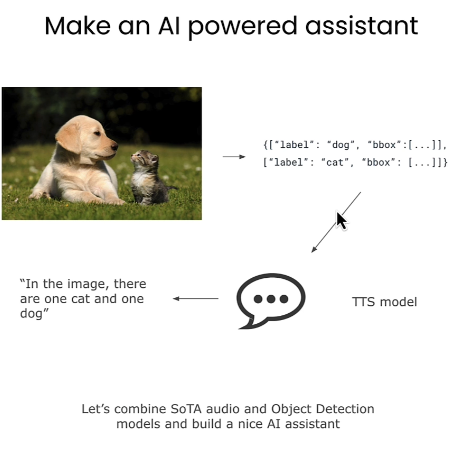

In [ ]:
# This is the output from the passed image, is an array of dictionaries with each
#corresponding to the label of the objects and the coordinates of the boubnding boxes
pipeline_output

[{'score': 0.9005734324455261,
  'label': 'traffic light',
  'box': {'xmin': 2932, 'ymin': 444, 'xmax': 3013, 'ymax': 558}},
 {'score': 0.548114001750946,
  'label': 'traffic light',
  'box': {'xmin': 2869, 'ymin': 386, 'xmax': 2994, 'ymax': 510}},
 {'score': 0.9963668584823608,
  'label': 'car',
  'box': {'xmin': 2915, 'ymin': 1448, 'xmax': 3279, 'ymax': 1733}},
 {'score': 0.8086340427398682,
  'label': 'car',
  'box': {'xmin': 2771, 'ymin': 741, 'xmax': 2959, 'ymax': 922}},
 {'score': 0.9319297075271606,
  'label': 'traffic light',
  'box': {'xmin': 2439, 'ymin': 444, 'xmax': 2511, 'ymax': 533}},
 {'score': 0.9902729392051697,
  'label': 'traffic light',
  'box': {'xmin': 2015, 'ymin': 281, 'xmax': 2139, 'ymax': 482}},
 {'score': 0.6910083889961243,
  'label': 'person',
  'box': {'xmin': 3848, 'ymin': 1900, 'xmax': 3980, 'ymax': 1993}},
 {'score': 0.5517910718917847,
  'label': 'bench',
  'box': {'xmin': 1080, 'ymin': 1511, 'xmax': 1310, 'ymax': 1706}},
 {'score': 0.9933801889419556,

The idea is the to pass tjis output to a text to speech model that tells us what is in the image.

In [ ]:
#Lets call the pipeline
od_pipe

ObjectDetectionPipeline: {'model': 'DetrForObjectDetection', 'dtype': 'float32', 'device': 'cuda', 'input_modalities': ('image',)}

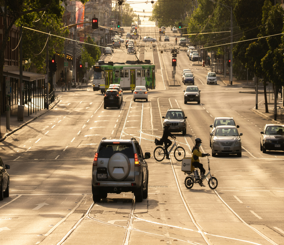

In [ ]:
#raw_image = Image.open('huggingface_friends.jpg')
raw_image.resize((284, 245))

In [ ]:
from helper import summarize_predictions_natural_language

In [ ]:
text = summarize_predictions_natural_language(pipeline_output)

In [ ]:
text

'In this image, there are fifteen traffic lights twenty-six cars thirteen persons one bench six bicycles one bus two trains and one motorcycle.'

### Generate Audio Narration of an Image

In [ ]:
from transformers import pipeline
from scipy.io.wavfile import write
from IPython.display import Audio

In [ ]:
# create a pipeline
tts_pipe = pipeline(
    "text-to-speech",
    model="facebook/mms-tts-eng"
)

config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  145MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/413 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/47.0 [00:00<?, ?B/s]

In [ ]:
#Pass the generated text
narrated_text = tts_pipe(text)

audio = narrated_text["audio"].squeeze()
sampling_rate = narrated_text["sampling_rate"]

# write("narration.wav", sampling_rate, audio)
Audio(audio, rate=sampling_rate)

### Play the Generated Audio

In [ ]:
from IPython.display import Audio as IPythonAudio

In [ ]:
IPythonAudio(narrated_text["audio"],
             rate=narrated_text["sampling_rate"])

### Try it yourself!
- Try these models with other images!

In [ ]:
# Let's try another model
from transformers import pipeline
from scipy.io.wavfile import write

tts_pipe = pipeline(
    "text-to-speech",
    model="suno/bark-small",
    device=0  # Remove this line if no GPU is available
)



config.json:   0%|          | 0.00/8.80k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.68GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/542 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.68GB            

...

tokenizer_config.json:   0%|          | 0.00/353 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

speaker_embeddings_path.json:   0%|          | 0.00/61.1k [00:00<?, ?B/s]

In [ ]:
# Pass again the text into the pipeline
result = tts_pipe(
    text,
    forward_params={"do_sample": True}
)

write(
    "narration.wav",
    result["sampling_rate"],
    result["audio"].squeeze()
)

In [ ]:
Audio(
    result["audio"].squeeze(),
    rate=result["sampling_rate"]
)

In [ ]:
text_2="No short-term post-installation reduction was therefore applied. Potential negative skin friction would require separate consideration if continuing consolidation or creep-prone sediments were identified."

In [ ]:
# This is more clear
result = tts_pipe(
    text_2,
    forward_params={"do_sample": True}
)

write(
    "narration2.wav",
    result["sampling_rate"],
    result["audio"].squeeze()
)

Audio("narration2.wav")